In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('Airbnb_Data.csv')
df.head(10)

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0
5,12422935,4.442651,Apartment,Private room,"{TV,""Wireless Internet"",Heating,""Smoke detecto...",2,1.0,Real Bed,strict,True,...,37.753164,-122.429526,Comfort Suite San Francisco,Noe Valley,3,100.0,https://a0.muscache.com/im/pictures/82509143-4...,94131,1.0,1.0
6,11825529,4.418841,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",3,1.0,Real Bed,moderate,True,...,33.980454,-118.462821,Beach Town Studio and Parking!!!11h,NaN,15,97.0,https://a0.muscache.com/im/pictures/4c920c60-4...,90292,1.0,1.0
7,13971273,4.787492,Condominium,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Wheelchair...",2,1.0,Real Bed,moderate,True,...,34.046737,-118.260439,"Near LA Live, Staple's. Starbucks inside. OWN ...",Downtown,9,93.0,https://a0.muscache.com/im/pictures/61bd05d5-c...,90015,1.0,1.0
8,180792,4.787492,House,Private room,"{TV,""Cable TV"",""Wireless Internet"",""Pets live ...",2,1.0,Real Bed,moderate,True,...,37.781128,-122.501095,Cozy Garden Studio - Private Entry,Richmond District,159,99.0,https://a0.muscache.com/im/pictures/0ed6c128-7...,94121,1.0,1.0
9,5385260,3.583519,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",2,1.0,Real Bed,moderate,True,...,33.992563,-117.895997,No.7 Queen Size Cozy Room 舒适大床房,NaN,2,90.0,https://a0.muscache.com/im/pictures/8d2f08ce-b...,91748,1.0,1.0


| # | Column Name                  |  Description                                                                  |
|---|------------------------------|---------------------------------------------------------------------------------------|
| 0 | log_price                    |  Logarithm of the listing price (normalized price)                        |
| 1 | property_type                |  Type of property (e.g., apartment, house, villa)                                      |
| 2 | room_type                    | Type of room (e.g., entire home, private room, shared room)                           |
| 3 | amenities                    |  List of amenities provided in the listing                                             |
| 4 | accommodates                 |  Maximum number of guests the property can accommodate                                 |
| 5 | bathrooms                    | Number of bathrooms (fractional values may indicate half-baths)                       |
| 6 | bed_type                     |  Type of bed(s) available (e.g., real bed, pull-out sofa)                              |
| 7 | cancellation_policy            | Policy for cancellations (e.g., flexible, moderate, strict)                          |
| 8 | cleaning_fee                  | Whether a cleaning fee is charged (True/False)                                        |
| 9 | city                            | City where the property is located                                                    |
| 10| description                  | Text description of the property (6 null values)                                      |
| 11| host_has_profile_pic         | Whether the host has a profile picture (likely 't'/'f' or similar)                    |
| 12| host_identity_verified       | Whether the host's identity is verified (likely 't'/'f' or similar)                   |
| 13| host_response_rate           | Percentage of messages the host responds to (may be scaled)                           |
| 14| instant_bookable             | Whether the property can be booked instantly (likely 't'/'f' or similar)              |
| 15| name                         | Name/title of the listing (10 null values)                                            |
| 16| number_of_reviews            | Total number of reviews the property has received                                     |
| 17| review_scores_rating         | Average review score/rating (likely on a scale like 0-100)                            |
| 18| bedrooms                     |  Number of bedrooms in the property                                                    |
| 19| beds                         | Total number of beds available                                                        |
| 20| distance_from_city_center    |  Distance from city center (units not specified - likely miles or km)                  |
| 21| years_since_last_review      |  Years since the property received its last review                                     |
| 22| years_since_host             |  Years since the host joined the platform                                              |

In [4]:
# Check dataframe info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

In [5]:
# Check statistical summary
print(df.describe())

                 id     log_price  accommodates     bathrooms      latitude  \
count  7.411100e+04  74111.000000  74111.000000  73911.000000  74111.000000   
mean   1.126662e+07      4.782069      3.155146      1.235263     38.445958   
std    6.081735e+06      0.717394      2.153589      0.582044      3.080167   
min    3.440000e+02      0.000000      1.000000      0.000000     33.338905   
25%    6.261964e+06      4.317488      2.000000      1.000000     34.127908   
50%    1.225415e+07      4.709530      2.000000      1.000000     40.662138   
75%    1.640226e+07      5.220356      4.000000      1.000000     40.746096   
max    2.123090e+07      7.600402     16.000000      8.000000     42.390437   

          longitude  number_of_reviews  review_scores_rating      bedrooms  \
count  74111.000000       74111.000000          57389.000000  74020.000000   
mean     -92.397525          20.900568             94.067365      1.265793   
std       21.705322          37.828641              7.

# DATA PREPROCESSING

**1. HANDLING MISSING AND DUPLICATED VALUES**

In [6]:
# Check for duplicated values:
print(df.duplicated().any().any())

False


In [7]:
# Check for missing values
print(df.isnull().sum())

id                            0
log_price                     0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                   200
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
description                   0
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
instant_bookable              0
last_review               15827
latitude                      0
longitude                     0
name                          0
neighbourhood              6872
number_of_reviews             0
review_scores_rating      16722
thumbnail_url              8216
zipcode                     966
bedrooms                     91
beds                        131
dtype: int64


In [8]:
# As we can check we have plenty of NA's values in the following variables --> 'Bathrooms' / 'first_review' / 'profile picture' / 
# 'id_verified' / 'response rate' / 'host_since / 'last_review' / 'neighbourhood' / 'scores rating' / 'thumbnail url' / 'zipcode' / 'bedrooms' / 'bed'

In [9]:
# MEAN / MEDIAN IMPUTATION:
# For variables like bathrooms, bedrooms and beds we can manually input mean/median to fill those NA values as the nº of missing values is low:
# Median imputation
df['bathrooms'].fillna(df['bathrooms'].median(), inplace=True)
df['bedrooms'].fillna(df['bedrooms'].median(), inplace=True)
df['beds'].fillna(df['beds'].median(), inplace=True)
df['review_scores_rating'].fillna(df['review_scores_rating'].mean(), inplace=True)
# Also, review score rating is a valid option for this method, albeit the amount is higher we should not eliminate those values.

In [10]:
# For url variable, as it is a link we can convert into a binary variable that has 0 if there is no link and 1 if it has:

In [11]:
# Convert thumbnail_url to binary indicator: 1 if there's a link, 0 otherwise
df['has_url'] = df['thumbnail_url'].notna().astype(int)

# Drop the original URL column:
# df.drop('thumbnail_url', axis=1, inplace=True)

In [12]:
print(df['host_response_rate'].value_counts())

host_response_rate
100%    43254
90%      2277
80%      1113
0%        883
50%       611
        ...  
39%         1
15%         1
31%         1
21%         1
6%          1
Name: count, Length: 80, dtype: int64


In [13]:
# We can check that a median imputation works for response rate as the variable contains values from 0-100 %
# Convert to float first so we can work with median:
df['host_response_rate'] = df['host_response_rate'].str.rstrip('%').astype(float) / 100
df['host_response_rate'].fillna(df['host_response_rate'].mean(), inplace=True)

In [14]:
# Now lets check the variable host since:
print(df['host_since'].value_counts())

host_since
2015-03-30    246
2014-02-14    173
2015-05-18     83
2016-09-16     83
2015-07-06     82
             ... 
2009-04-08      1
2009-11-22      1
2010-02-28      1
2009-05-11      1
2009-08-23      1
Name: count, Length: 3087, dtype: int64


In [15]:
# As we can see, it is a date format variable, as we know we cannot input mean/median as it is not treated as a number, however, 
# we can convert this variable instead of giving a date, the number of days since the host joined AirBNB so in fact it will be a number we can work more easily with:

In [16]:
# As we can check the same case can be applied to last_review and first review:
print(df['last_review'].value_counts())

last_review
2017-04-30    1344
2017-09-24    1278
2017-09-17    1215
2017-04-23    1025
2017-09-18     832
              ... 
2013-12-11       1
2014-06-19       1
2013-10-26       1
2011-03-28       1
2013-12-28       1
Name: count, Length: 1371, dtype: int64


In [17]:
print(df['first_review'].value_counts())

first_review
2017-01-01    293
2017-01-22    249
2016-01-02    221
2017-01-02    211
2017-09-04    193
             ... 
2012-12-09      1
2012-04-20      1
2010-11-29      1
2011-03-28      1
2010-12-01      1
Name: count, Length: 2554, dtype: int64


In [18]:
# Convert variables to datetime:
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce')
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

In [19]:
# Reference date (e.g. today or dataset's collection date)
reference_date = pd.to_datetime('2018-01-01')
# Days since host joined
df['days_since_host'] = (reference_date - df['host_since']).dt.days

# Days since last review
df['days_since_last_review'] = (reference_date - df['last_review']).dt.days

# Days since first review
df['days_since_first_review'] = (reference_date - df['first_review']).dt.days

In [20]:
# Fill missing values with median
df['days_since_host'].fillna(df['days_since_host'].median(), inplace=True)
df['days_since_first_review'].fillna(df['days_since_first_review'].median(), inplace=True)
df['days_since_last_review'].fillna(df['days_since_last_review'].median(), inplace=True)

In [21]:
# Here for both profile picture and identity verified, we check it is a binary variable with True/False values, so this Na can be manually input as False values:
print(df['host_has_profile_pic'].value_counts())
print(df['host_identity_verified'].value_counts())

host_has_profile_pic
t    73697
f      226
Name: count, dtype: int64
host_identity_verified
t    49748
f    24175
Name: count, dtype: int64


In [22]:
df['host_has_profile_pic'].fillna("f", inplace=True)
df['host_identity_verified'].fillna("f", inplace=True)

In [23]:
# neighbourhood and zipcode:
# OPTION 1: Create a new category for the NA's values --> Missing
df['neighbourhood'].fillna("missing", inplace=True)
df['zipcode'].fillna("missing", inplace=True)

# Option 2: As we have latitude and longitude variables, we can define a function that identifies the correspondent value for the NA's:

In [24]:
print(df.isnull().sum())

id                             0
log_price                      0
property_type                  0
room_type                      0
amenities                      0
accommodates                   0
bathrooms                      0
bed_type                       0
cancellation_policy            0
cleaning_fee                   0
city                           0
description                    0
first_review               15864
host_has_profile_pic           0
host_identity_verified         0
host_response_rate             0
host_since                   188
instant_bookable               0
last_review                15827
latitude                       0
longitude                      0
name                           0
neighbourhood                  0
number_of_reviews              0
review_scores_rating           0
thumbnail_url               8216
zipcode                        0
bedrooms                       0
beds                           0
has_url                        0
days_since

In [25]:
# As we can observe we got rid of all NA's, we dont need to worry for first_review/last_review/url variables 
# as we will drop them or we will create a new df without these variables for model training:

In [26]:
# Define columns to drop (the original date columns you replaced)
columns_to_drop = ['host_since', 'first_review', 'last_review', 'thumbnail_url']

# Create the clean dataframe
clean_df = df.drop(columns=columns_to_drop).copy()

In [27]:
print(clean_df.isnull().sum())

id                         0
log_price                  0
property_type              0
room_type                  0
amenities                  0
accommodates               0
bathrooms                  0
bed_type                   0
cancellation_policy        0
cleaning_fee               0
city                       0
description                0
host_has_profile_pic       0
host_identity_verified     0
host_response_rate         0
instant_bookable           0
latitude                   0
longitude                  0
name                       0
neighbourhood              0
number_of_reviews          0
review_scores_rating       0
zipcode                    0
bedrooms                   0
beds                       0
has_url                    0
days_since_host            0
days_since_last_review     0
days_since_first_review    0
dtype: int64


In [28]:
clean_df.shape

(74111, 29)

In [29]:
# For the training and model development we can get rid of id variable as it may not be neccesary:
clean_df = clean_df.drop('id', axis=1)

In [30]:
clean_df.head()

,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds,has_url,days_since_host,days_since_last_review,days_since_first_review
0,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,...,Brooklyn Heights,2,100.000000,11201,1.0,1.0,1,2107.0,532.0,562.0
1,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,...,Hell's Kitchen,6,93.000000,10019,3.0,3.0,1,196.0,100.0,149.0
2,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,...,Harlem,10,92.000000,10027,1.0,3.0,1,433.0,109.0,246.0
3,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,SF,...,Lower Haight,0,94.067365,94117.0,2.0,2.0,1,988.0,248.0,586.0
4,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,...,Columbia Heights,4,40.000000,20009,0.0,1.0,0,1037.0,344.0,965.0


**2. DATA ENCODING AND NORMALIZATION**

In [31]:
# First lets check the structure of our categorical valriables one-by-one to identify which encoding startegy fits it better:
# Property Type:
clean_df['property_type'].value_counts()

property_type
Apartment             49003
House                 16511
Condominium            2658
Townhouse              1692
Loft                   1244
Other                   607
Guesthouse              498
Bed & Breakfast         462
Bungalow                366
Villa                   179
Dorm                    142
Guest suite             123
Camper/RV                94
Timeshare                77
Cabin                    72
In-law                   71
Hostel                   70
Boutique hotel           69
Boat                     65
Serviced apartment       21
Tent                     18
Castle                   13
Vacation home            11
Yurt                      9
Hut                       8
Treehouse                 7
Chalet                    6
Earth House               4
Tipi                      3
Train                     2
Cave                      2
Casa particular           1
Parking Space             1
Lighthouse                1
Island                    1
Name: 

In [32]:
# With over 30 unique values, many with super low frequency, the best approach is:
# 1. Group rare types into "Other"
# 2. One-hot encode the simplified version.

# Step 1: Group rare categories into "Other"
top6_property_types = clean_df['property_type'].value_counts().nlargest(6).index
clean_df['property_type'] = clean_df['property_type'].where(clean_df['property_type'].isin(top6_property_types), other='Other')

# Step 2: One-hot encode
encode_df = pd.get_dummies(clean_df, columns=['property_type'], drop_first=True)

In [33]:
# ROOM TYPE:
clean_df['room_type'].value_counts()

room_type
Entire home/apt    41310
Private room       30638
Shared room         2163
Name: count, dtype: int64

In [34]:
# BED TYPE:
clean_df['bed_type'].value_counts()

bed_type
Real Bed         72028
Futon              753
Pull-out Sofa      585
Airbed             477
Couch              268
Name: count, dtype: int64

In [35]:
# ONE-HOT Encoding
clean_df['city'].value_counts()

city
NYC        32349
LA         22453
SF          6434
DC          5688
Chicago     3719
Boston      3468
Name: count, dtype: int64

In [36]:
# ONE-HOT Encoding for all our variables mentioned before:
encode_df = pd.get_dummies(encode_df, columns=['room_type', 'city', 'bed_type'], drop_first=True)

In [37]:
# CANCELLATION POLICY: --> Apply Ordinal Encoding as we can apply levels in the unique values:
clean_df['cancellation_policy'].value_counts()

cancellation_policy
strict             32374
flexible           22545
moderate           19063
super_strict_30      112
super_strict_60       17
Name: count, dtype: int64

In [38]:
# Ordinal encoding for cancellation policy:
cancel_policy_order = {
    'flexible': 0,
    'moderate': 1,
    'strict': 2,
    'super_strict_30': 3,
    'super_strict_60': 4
}
encode_df['cancellation_policy'] = clean_df['cancellation_policy'].map(cancel_policy_order)

In [39]:
clean_df['neighbourhood'].value_counts()

neighbourhood
missing               6872
Williamsburg          2862
Bedford-Stuyvesant    2166
Bushwick              1601
Upper West Side       1396
                      ... 
Mill Basin               1
Mt. Vernon Square        1
Chevy Chase, MD          1
Clearing                 1
Grant City               1
Name: count, Length: 620, dtype: int64

In [40]:
# We decided to get rid of variables neighbourhood, description, name, amenities, zipcode since they wont add anything relevant to our models 
# and in the case of neighbourhood adn zipcode we already have city, latitude and longitude as location. 
encode_df = encode_df.drop(['neighbourhood', 'description', 'name', 'amenities', 'zipcode'], axis=1)

In [41]:
encode_df.head()

,log_price,accommodates,bathrooms,cancellation_policy,cleaning_fee,host_has_profile_pic,host_identity_verified,host_response_rate,instant_bookable,latitude,...,room_type_Shared room,city_Chicago,city_DC,city_LA,city_NYC,city_SF,bed_type_Couch,bed_type_Futon,bed_type_Pull-out Sofa,bed_type_Real Bed
0,5.010635,3,1.0,2,True,t,t,0.94352,f,40.696524,...,False,False,False,False,True,False,False,False,False,True
1,5.129899,7,1.0,2,True,t,f,1.00000,t,40.766115,...,False,False,False,False,True,False,False,False,False,True
2,4.976734,5,1.0,1,True,t,t,1.00000,t,40.808110,...,False,False,False,False,True,False,False,False,False,True
3,6.620073,4,1.0,0,True,t,t,0.94352,f,37.772004,...,False,False,False,False,False,True,False,False,False,True
4,4.744932,2,1.0,1,True,t,t,1.00000,t,38.925627,...,False,False,True,False,False,False,False,False,False,True


In [42]:
# We need to convert those t and f values into binary variable with 0 and 1s:
encode_df['instant_bookable'].value_counts()

instant_bookable
f    54660
t    19451
Name: count, dtype: int64

In [43]:
encode_df['instant_bookable'] = encode_df['instant_bookable'].map({'f': 0, 't': 1})
encode_df['host_has_profile_pic'] = encode_df['host_has_profile_pic'].map({'f': 0, 't': 1})
encode_df['host_identity_verified'] = encode_df['host_identity_verified'].map({'f': 0, 't': 1})

In [44]:
# Same process for one_hot encoding variables from before:
# Automatically convert all boolean columns to integers (0/1)
bool_cols = encode_df.select_dtypes(include='bool').columns
encode_df[bool_cols] = encode_df[bool_cols].astype(int)
encode_df.head()

,log_price,accommodates,bathrooms,cancellation_policy,cleaning_fee,host_has_profile_pic,host_identity_verified,host_response_rate,instant_bookable,latitude,...,room_type_Shared room,city_Chicago,city_DC,city_LA,city_NYC,city_SF,bed_type_Couch,bed_type_Futon,bed_type_Pull-out Sofa,bed_type_Real Bed
0,5.010635,3,1.0,2,1,1,1,0.94352,0,40.696524,...,0,0,0,0,1,0,0,0,0,1
1,5.129899,7,1.0,2,1,1,0,1.00000,1,40.766115,...,0,0,0,0,1,0,0,0,0,1
2,4.976734,5,1.0,1,1,1,1,1.00000,1,40.808110,...,0,0,0,0,1,0,0,0,0,1
3,6.620073,4,1.0,0,1,1,1,0.94352,0,37.772004,...,0,0,0,0,0,1,0,0,0,1
4,4.744932,2,1.0,1,1,1,1,1.00000,1,38.925627,...,0,0,1,0,0,0,0,0,0,1


In [45]:
encode_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   log_price                  74111 non-null  float64
 1   accommodates               74111 non-null  int64  
 2   bathrooms                  74111 non-null  float64
 3   cancellation_policy        74111 non-null  int64  
 4   cleaning_fee               74111 non-null  int32  
 5   host_has_profile_pic       74111 non-null  int64  
 6   host_identity_verified     74111 non-null  int64  
 7   host_response_rate         74111 non-null  float64
 8   instant_bookable           74111 non-null  int64  
 9   latitude                   74111 non-null  float64
 10  longitude                  74111 non-null  float64
 11  number_of_reviews          74111 non-null  int64  
 12  review_scores_rating       74111 non-null  float64
 13  bedrooms                   74111 non-null  flo

In [46]:
# Okay, now that we have our transformed (only numerical dataset), lets check for outliers in the values (non-boolean attributes):
encode_df[['accommodates', 'bathrooms', 'number_of_reviews', 'bedrooms', 'beds', 'days_since_host', 'days_since_last_review', 'days_since_first_review']].describe() 

,accommodates,bathrooms,number_of_reviews,bedrooms,beds,days_since_host,days_since_last_review,days_since_first_review
count,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000
mean,3.155146,1.234628,20.900568,1.265467,1.709611,1259.745193,282.752371,689.475989
std,2.153589,0.581386,37.828641,0.851671,1.253389,660.666662,206.297638,443.321798
min,1.000000,0.000000,0.000000,0.000000,0.000000,89.000000,88.000000,88.000000
25%,2.000000,1.000000,1.000000,1.000000,1.000000,742.000000,134.000000,432.000000
50%,2.000000,1.000000,6.000000,1.000000,1.000000,1191.000000,248.000000,586.000000
75%,4.000000,1.000000,23.000000,1.000000,2.000000,1715.000000,283.000000,833.000000
max,16.000000,8.000000,605.000000,10.000000,18.000000,3591.000000,3267.000000,3332.000000


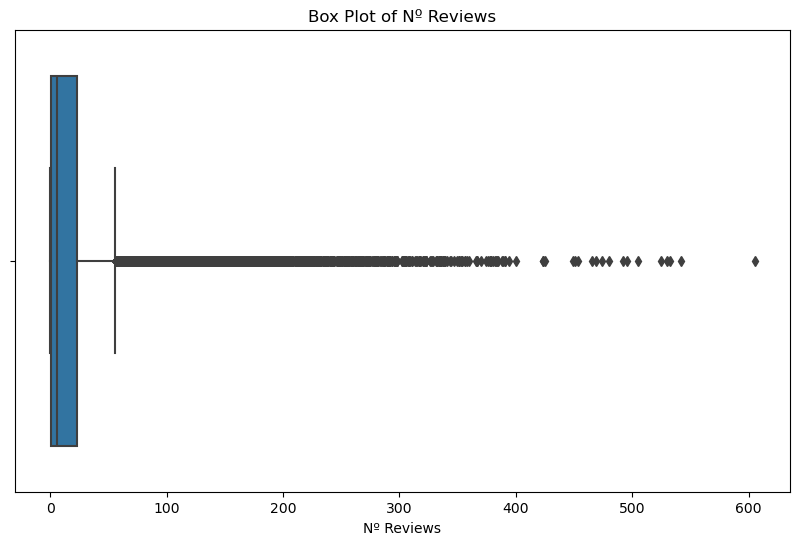

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x=encode_df['number_of_reviews'])
plt.title('Box Plot of Nº Reviews')
plt.xlabel('Nº Reviews')
plt.show()

In [48]:
# Apply log transformation get more balanced distribution with no extreme outliers: 
encode_df['log_number_of_reviews'] = np.log1p(encode_df['number_of_reviews'])

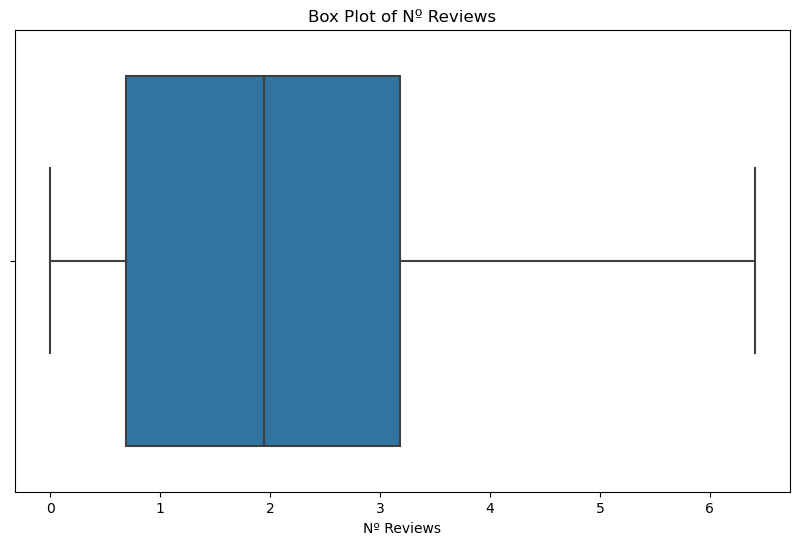

In [49]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=encode_df['log_number_of_reviews'])
plt.title('Box Plot of Nº Reviews')
plt.xlabel('Nº Reviews')
plt.show()

In [50]:
encode_df[['review_scores_rating', 'host_response_rate']].describe()

,review_scores_rating,host_response_rate
count,74111.000000,74111.000000
mean,94.067365,0.943520
std,6.896002,0.141815
min,20.000000,0.000000
25%,93.000000,0.943520
50%,94.067365,1.000000
75%,99.000000,1.000000
max,100.000000,1.000000


In [51]:
encode_df = encode_df.drop('number_of_reviews', axis=1)

In [52]:
encode_df.head()

,log_price,accommodates,bathrooms,cancellation_policy,cleaning_fee,host_has_profile_pic,host_identity_verified,host_response_rate,instant_bookable,latitude,...,city_Chicago,city_DC,city_LA,city_NYC,city_SF,bed_type_Couch,bed_type_Futon,bed_type_Pull-out Sofa,bed_type_Real Bed,log_number_of_reviews
0,5.010635,3,1.0,2,1,1,1,0.94352,0,40.696524,...,0,0,0,1,0,0,0,0,1,1.098612
1,5.129899,7,1.0,2,1,1,0,1.00000,1,40.766115,...,0,0,0,1,0,0,0,0,1,1.945910
2,4.976734,5,1.0,1,1,1,1,1.00000,1,40.808110,...,0,0,0,1,0,0,0,0,1,2.397895
3,6.620073,4,1.0,0,1,1,1,0.94352,0,37.772004,...,0,0,0,0,1,0,0,0,1,0.000000
4,4.744932,2,1.0,1,1,1,1,1.00000,1,38.925627,...,0,1,0,0,0,0,0,0,1,1.609438


In [53]:
encode_df.columns

Index(['log_price', 'accommodates', 'bathrooms', 'cancellation_policy',
       'cleaning_fee', 'host_has_profile_pic', 'host_identity_verified',
       'host_response_rate', 'instant_bookable', 'latitude', 'longitude',
       'review_scores_rating', 'bedrooms', 'beds', 'has_url',
       'days_since_host', 'days_since_last_review', 'days_since_first_review',
       'property_type_Condominium', 'property_type_House',
       'property_type_Loft', 'property_type_Other', 'property_type_Townhouse',
       'room_type_Private room', 'room_type_Shared room', 'city_Chicago',
       'city_DC', 'city_LA', 'city_NYC', 'city_SF', 'bed_type_Couch',
       'bed_type_Futon', 'bed_type_Pull-out Sofa', 'bed_type_Real Bed',
       'log_number_of_reviews'],
      dtype='object')

In [54]:
# log_price (target)
# accommodates // bathrooms // cleaning_fee // host_response_rate // latitude, longitude (possibly – but be careful, these are geospatial) // 
# review_scores_rating // bedrooms // beds // days_since_host // days_since_last_review // days_since_first_review // log_number_of_reviews

In [55]:
numerical_features = [
    'accommodates', 'bathrooms', 'cleaning_fee','host_response_rate','review_scores_rating', 'bedrooms', 'beds',
    'days_since_host', 'days_since_last_review', 'days_since_first_review',
    'log_number_of_reviews'
]

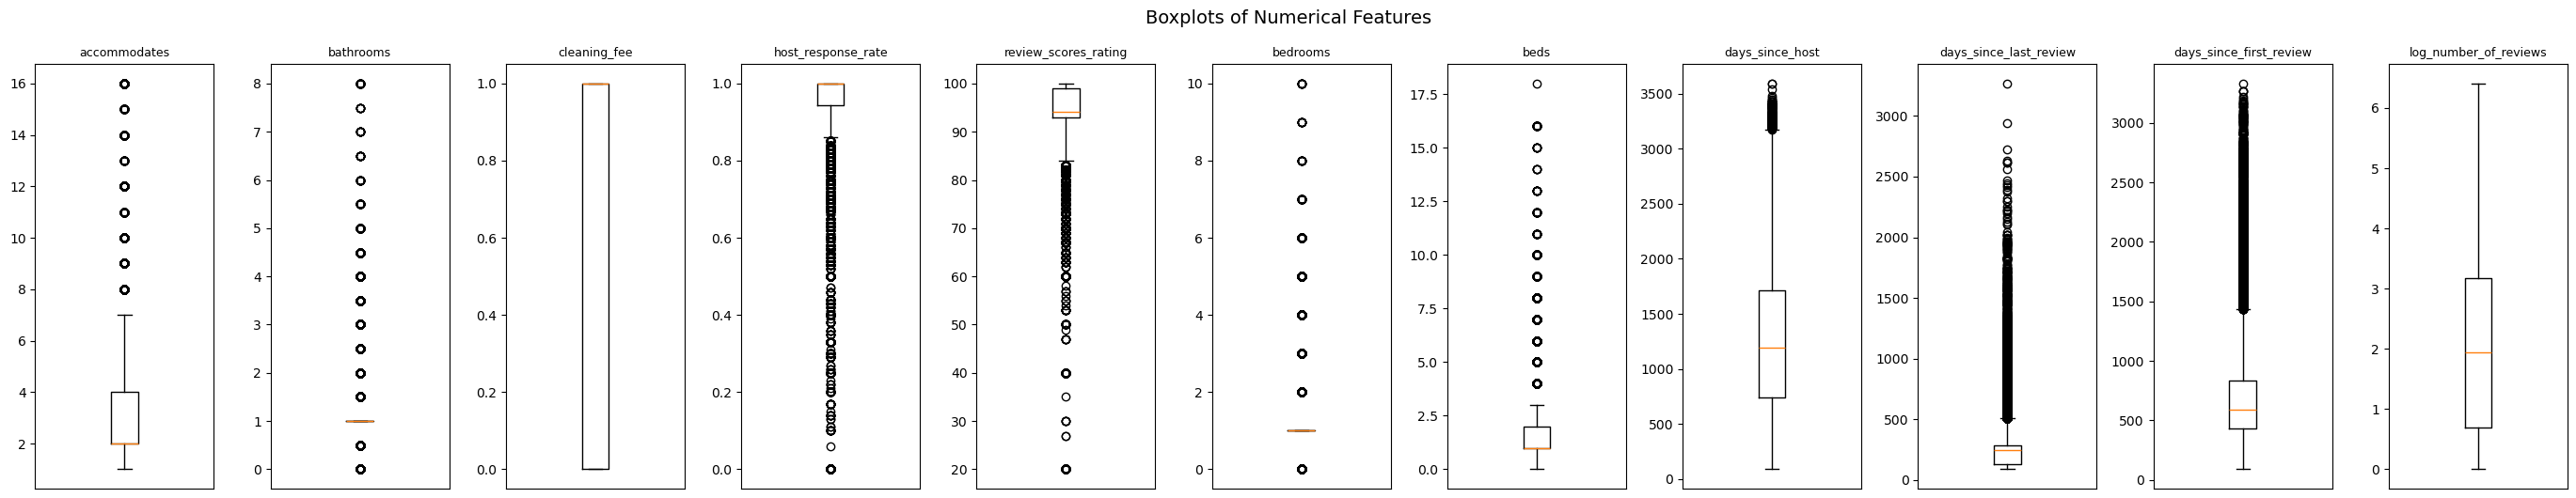

In [56]:
import matplotlib.pyplot as plt

# Number of features
features = numerical_features
num_features = len(features)

# Set up the figure
plt.figure(figsize=(2.5 * num_features, 5))  

# Plot each feature's boxplot in its own subplot
for i, feature in enumerate(features):
    plt.subplot(1, num_features, i + 1)  
    plt.boxplot(encode_df[feature])
    plt.title(feature, fontsize=9)
    plt.xticks([]) 
    plt.tight_layout()

plt.suptitle('Boxplots of Numerical Features', y=1.05, fontsize=14)
plt.show()

In [57]:
# We will foucs first in our created variables days_since_etc as they have very heavy tails and are skewed.

C:\Users\artur\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\artur\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\artur\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


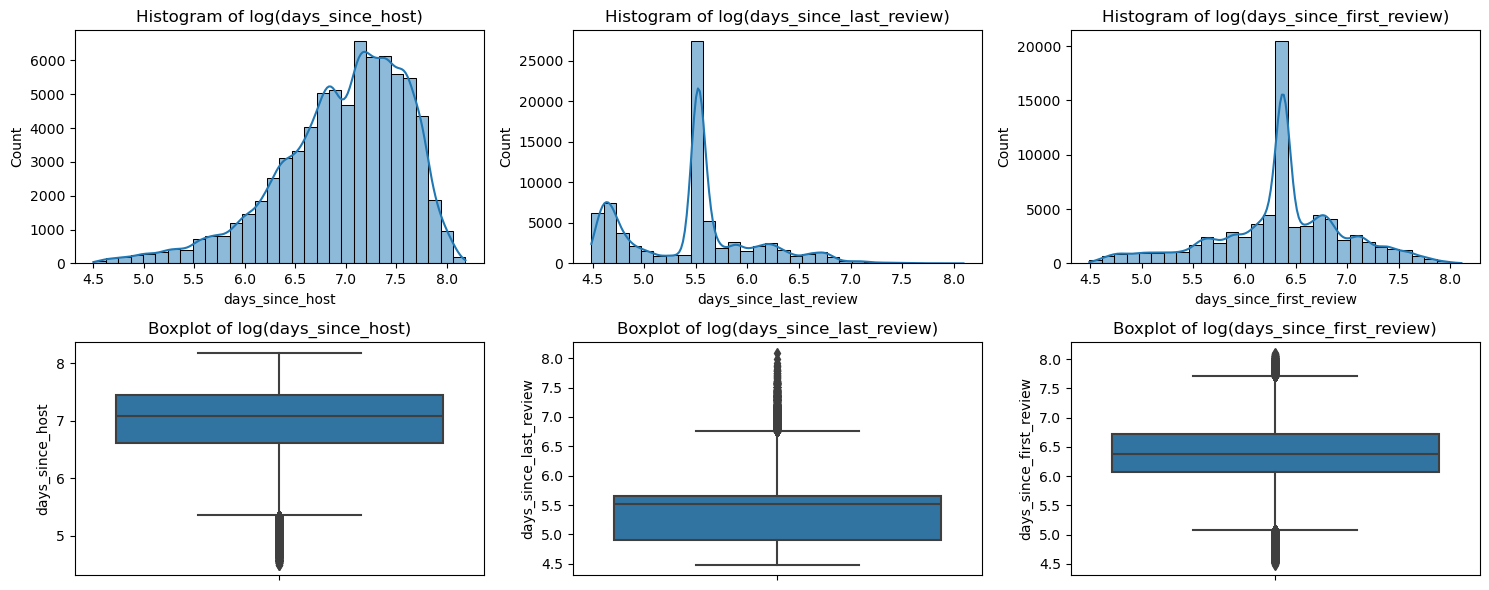

In [58]:
import numpy as np

# Columns to log-transform
days_features = ['days_since_host', 'days_since_last_review', 'days_since_first_review']

# Apply log(1 + x) to avoid log(0) issues
encode_df[days_features] = encode_df[days_features].apply(lambda x: np.log1p(x))

fig, axes = plt.subplots(2, 3, figsize=(15, 6))

for i, feature in enumerate(days_features):
    # Histogram
    sns.histplot(encode_df[feature], ax=axes[0, i], kde=True, bins=30)
    axes[0, i].set_title(f'Histogram of log({feature})')

    # Boxplot
    sns.boxplot(y=encode_df[feature], ax=axes[1, i])
    axes[1, i].set_title(f'Boxplot of log({feature})')

plt.tight_layout()
plt.show()

In [59]:
# Same process for the remaining variables that present outliers:
log_features = ['accommodates', 'bathrooms', 'beds', 'bedrooms']
encode_df[log_features] = encode_df[log_features].apply(lambda x: np.log1p(x))


In [60]:
# Normalize review_scores_rating to [0, 1]
encode_df['review_scores_rating'] = encode_df['review_scores_rating'] / 100

C:\Users\artur\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\artur\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\artur\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\artur\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

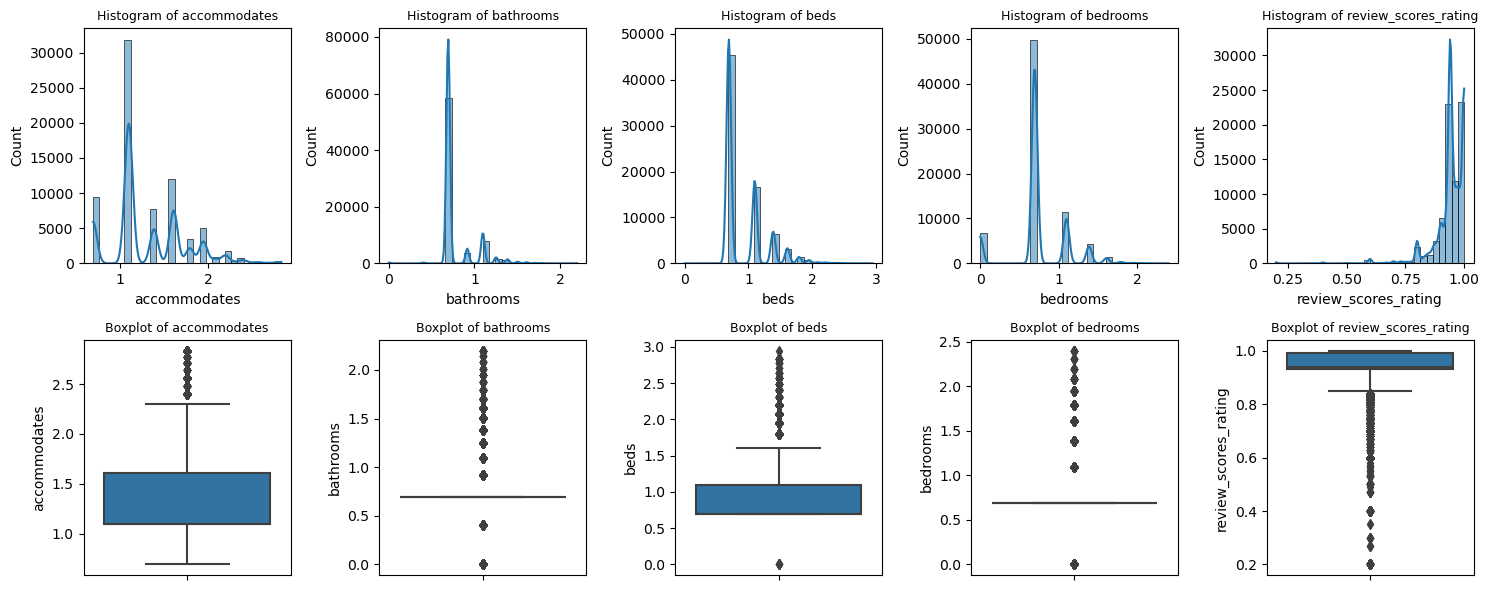

In [61]:
log_and_normalized_features = log_features + ['review_scores_rating']

# Set up the plots
fig, axes = plt.subplots(2, len(log_and_normalized_features), figsize=(3 * len(log_and_normalized_features), 6))

for i, feature in enumerate(log_and_normalized_features):
    # Histogram
    sns.histplot(encode_df[feature], ax=axes[0, i], kde=True, bins=30)
    axes[0, i].set_title(f'Histogram of {feature}', fontsize=9)

    # Boxplot
    sns.boxplot(y=encode_df[feature], ax=axes[1, i])
    axes[1, i].set_title(f'Boxplot of {feature}', fontsize=9)

plt.tight_layout()
plt.show()


In [62]:
# STANDARDIZATION OF NUMERICAL VARIABLES (Not including binary var. from categorical encoding)

In [63]:
to_scale = ['accommodates', 'bathrooms', 'beds', 'bedrooms',
            'days_since_host', 'days_since_last_review', 'days_since_first_review',
            'log_number_of_reviews']

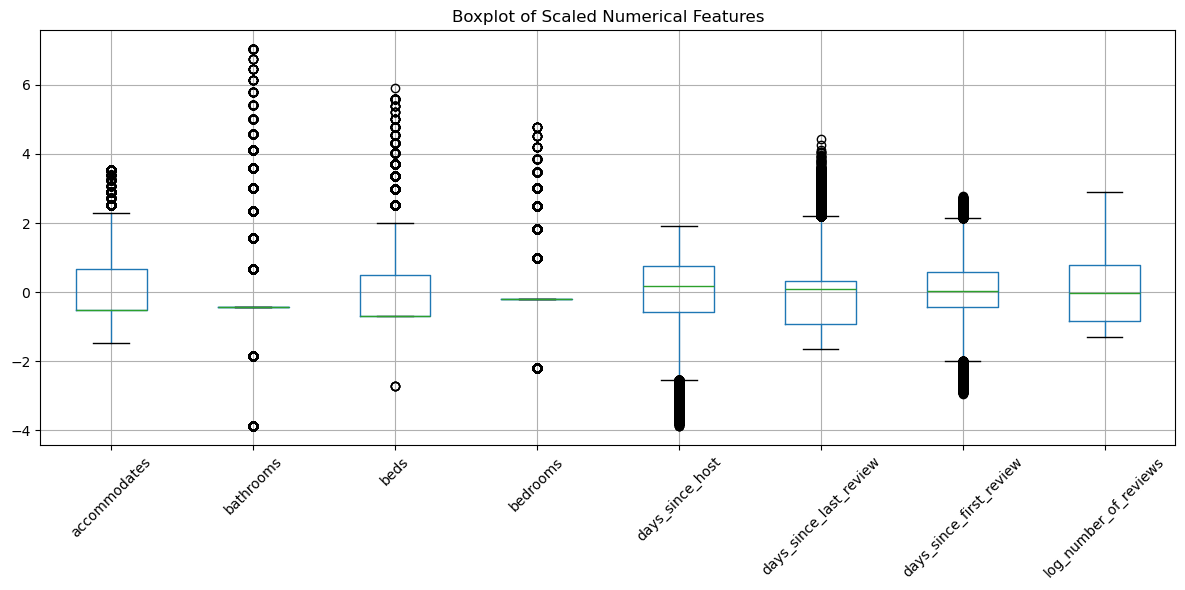

In [64]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
scaled_df = encode_df.copy()
scaled_df[to_scale] = scaler.fit_transform(scaled_df[to_scale])

plt.figure(figsize=(12, 6))
scaled_df[to_scale].boxplot(rot=45)
plt.title('Boxplot of Scaled Numerical Features')
plt.tight_layout()
plt.show()

------------

**3. CORRELATION AND HEATMAP**

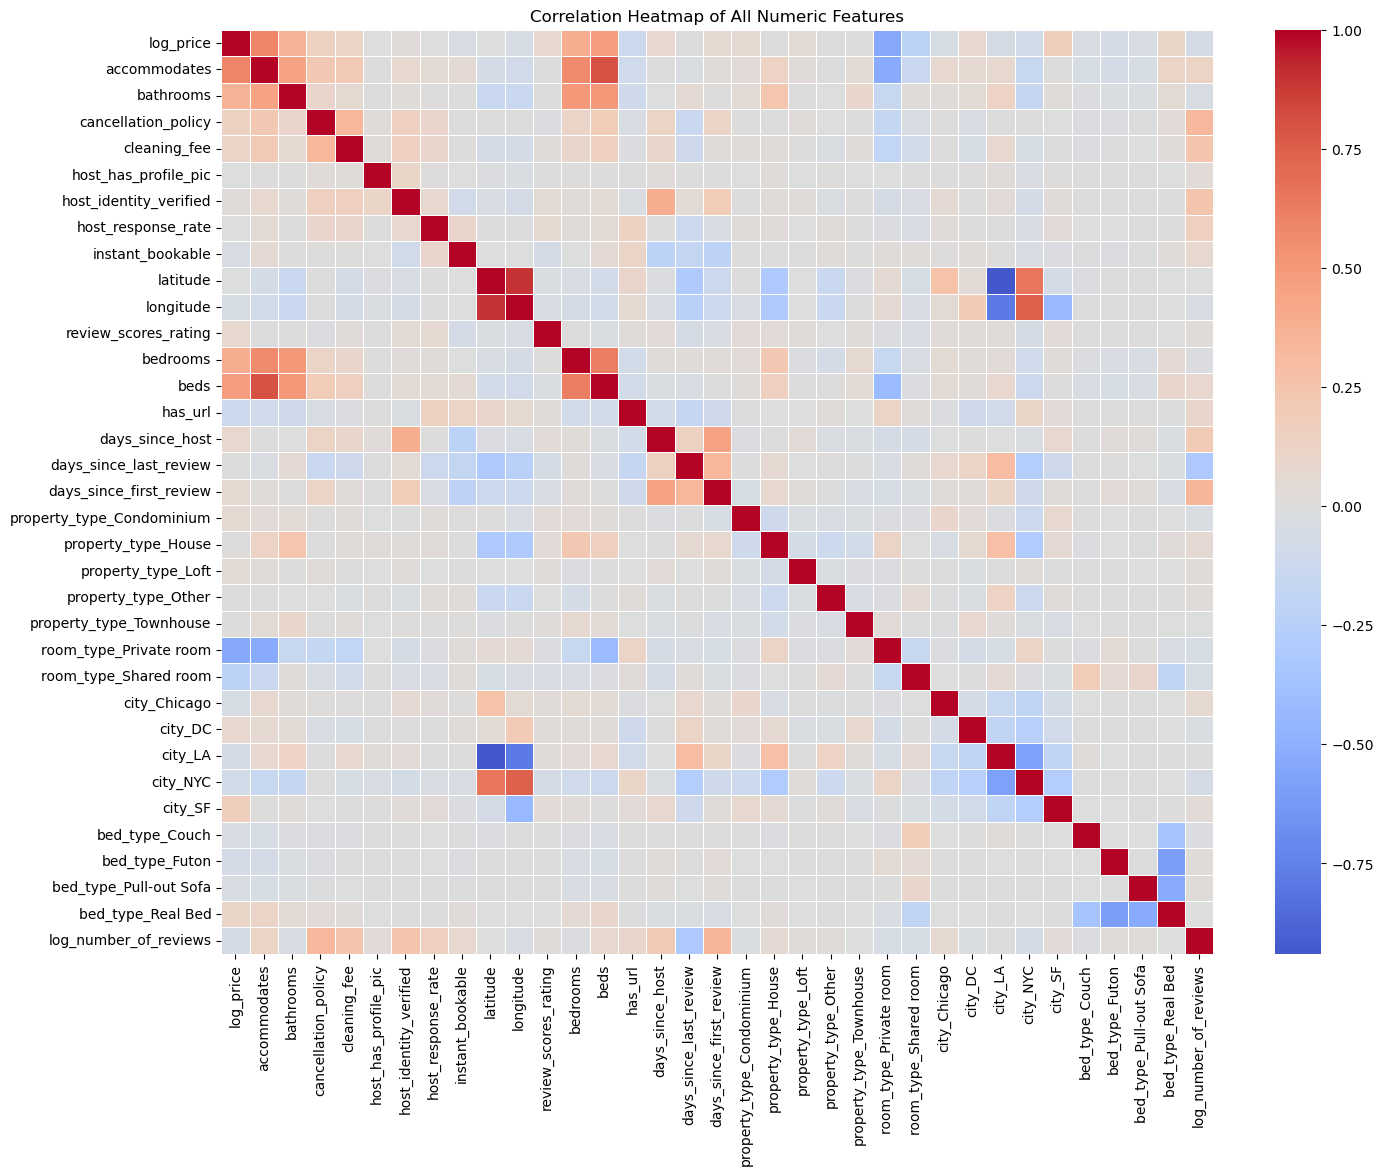

In [65]:
# Only keep numeric features
numeric_df = scaled_df.select_dtypes(include='number')

# Optional: drop target if you're only interested in feature-feature correlation
# numeric_df = numeric_df.drop(columns=['log_price'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5, center=0)
plt.title("Correlation Heatmap of All Numeric Features")
plt.show()


In [66]:
# Get absolute correlations with the target
target_corr = corr_matrix['log_price'].abs().sort_values(ascending=False)

# Select, say, the top 11 including log_price itself (so we'll have 10 features aside from the target)
top_corr_features = target_corr.head(11).index

print("Top correlated features:\n", target_corr.head(11))


Top correlated features:
 log_price                 1.000000
accommodates              0.595722
room_type_Private room    0.531648
beds                      0.484193
bedrooms                  0.390344
bathrooms                 0.361874
room_type_Shared room     0.222487
city_SF                   0.166738
cancellation_policy       0.131869
has_url                   0.125523
cleaning_fee              0.111191
Name: log_price, dtype: float64


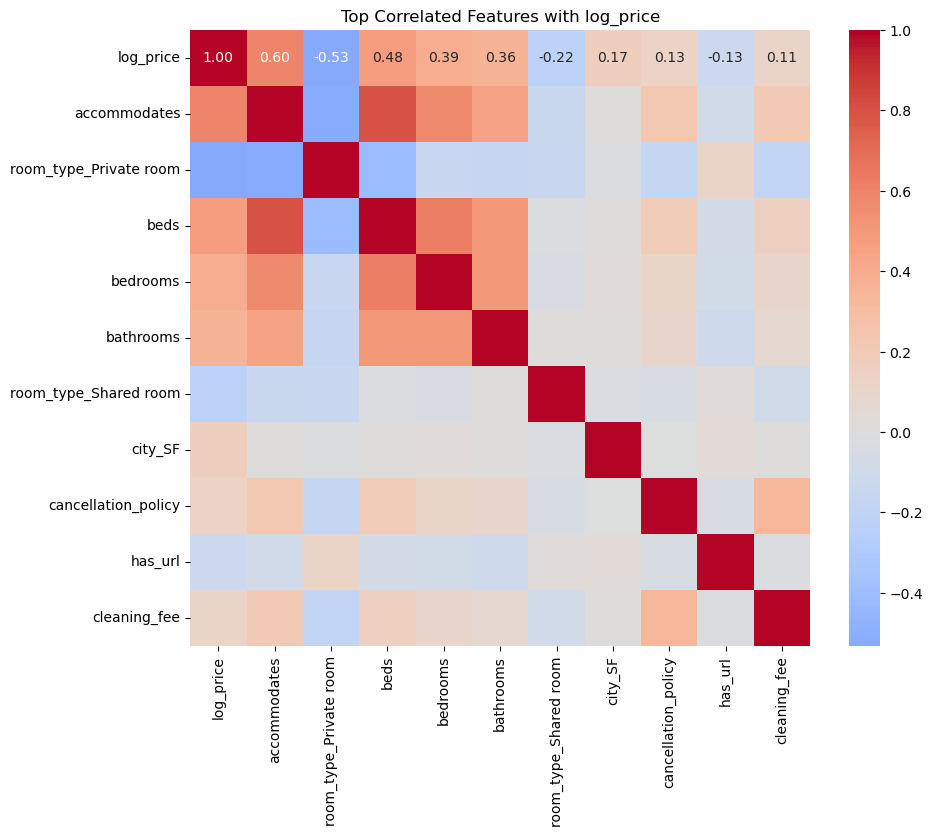

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(encode_df[top_corr_features].corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Top Correlated Features with log_price")
plt.show()


---

# DATA SPLIT

In [68]:
scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   log_price                  74111 non-null  float64
 1   accommodates               74111 non-null  float64
 2   bathrooms                  74111 non-null  float64
 3   cancellation_policy        74111 non-null  int64  
 4   cleaning_fee               74111 non-null  int32  
 5   host_has_profile_pic       74111 non-null  int64  
 6   host_identity_verified     74111 non-null  int64  
 7   host_response_rate         74111 non-null  float64
 8   instant_bookable           74111 non-null  int64  
 9   latitude                   74111 non-null  float64
 10  longitude                  74111 non-null  float64
 11  review_scores_rating       74111 non-null  float64
 12  bedrooms                   74111 non-null  float64
 13  beds                       74111 non-null  flo

In [69]:
X = scaled_df.drop('log_price', axis=1)
y = scaled_df['log_price']

In [70]:
# Split the dataset
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0)

In [71]:
X_train.shape, X_test.shape, X_val.shape

((44466, 34), (14823, 34), (14822, 34))

**Remember:**

Training set --> Used to fit/train the model

Validation set	--> Used to tune hyperparameters, compare models, and make decisions during development

Test set	--> Used once at the very end to report final, unbiased performance

# (LOG) PRICE PREDICTION MODEL DEVELOPMENT:

**LINEAR REGRESSION (benchmark)**

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred = lr_model.predict(X_val)

# Evaluate
mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("Linear Regression Performance on Validation Set:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

Linear Regression Performance on Validation Set:
RMSE: 0.4617
MAE: 0.3482
R²: 0.5884


**RANDOM FOREST**

In [73]:
from sklearn.ensemble import RandomForestRegressor

# Train RF model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=0, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred = rf_model.predict(X_val)

# Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("Random Forest Performance on Validation Set:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

Random Forest Performance on Validation Set:
RMSE: 0.3942
MAE: 0.2825
R²: 0.6999


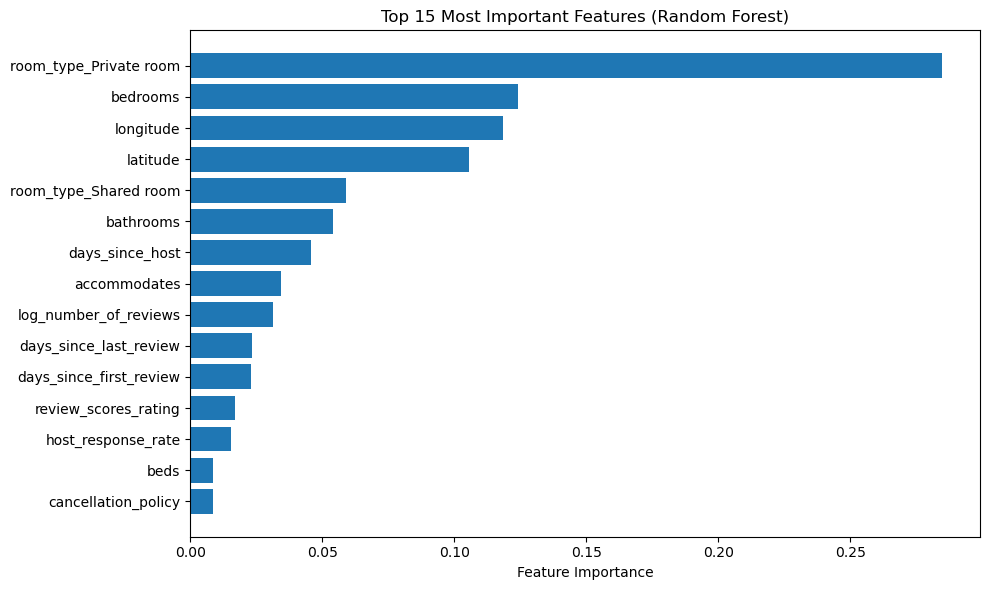

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the trained RF model
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for easier sorting/plotting
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top N features
top_n = 15
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'][:top_n][::-1], feature_imp_df['Importance'][:top_n][::-1])
plt.title(f"Top {top_n} Most Important Features (Random Forest)")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()


In [75]:
# Step 1: Feature Selection
# Based on the feature importance plot, let’s take the top N features (e.g., top 10 or 15):
top_n = 15
top_features = feature_imp_df['Feature'].head(top_n).tolist()

# Filter X sets
X_train_top = X_train[top_features]
X_val_top = X_val[top_features]
X_test_top = X_test[top_features]

In [76]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import time

# Start timer
start_time = time.time()

rf = RandomForestRegressor(random_state=0)

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

grid_search.fit(X_train_top, y_train)

# End timer
end_time = time.time()
elapsed_time = end_time - start_time

best_rf = grid_search.best_estimator_
print("Best Parameters Found:", grid_search.best_params_)
print(f"\n⏱️ Grid search completed in {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")

Best Parameters Found: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}

⏱️ Grid search completed in 3070.68 seconds (51.18 minutes)


In [77]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict
y_val_pred = best_rf.predict(X_val_top)

# Evaluate
rmse = mean_squared_error(y_val, y_val_pred, squared=False)
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("Best Random Forest Performance on Validation Set:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

Best Random Forest Performance on Validation Set:
RMSE: 0.3946
MAE: 0.2828
R²: 0.6994


In [82]:
# Use full feature set (not just top 15)
best_rf_all = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=0,
    n_jobs=-1
)

best_rf_all.fit(X_train, y_train)

# Evaluate on val set
y_val_pred_all = best_rf_all.predict(X_val)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
rmse_all = mean_squared_error(y_val, y_val_pred_all, squared=False)
mae_all = mean_absolute_error(y_val, y_val_pred_all)
r2_all = r2_score(y_val, y_val_pred_all)

print("Full-Feature RF Performance:")
print(f"RMSE: {rmse_all:.4f}")
print(f"MAE: {mae_all:.4f}")
print(f"R²: {r2_all:.4f}")

Full-Feature RF Performance:
RMSE: 0.3920
MAE: 0.2813
R²: 0.7033


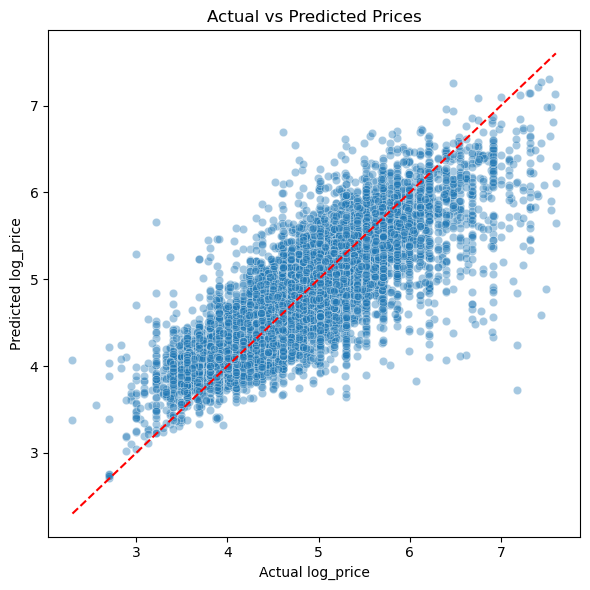

In [78]:
# Evaluate the best model on the test set

y_test_pred = best_rf.predict(X_test_top)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual log_price')
plt.ylabel('Predicted log_price')
plt.title('Actual vs Predicted Prices')
plt.tight_layout()
plt.show()


**LASSO and RIDGE**

In [85]:
from sklearn.linear_model import Ridge, Lasso

# RIDGE

# Alpha values to search
alphas = [0.001, 0.01, 0.1, 1, 10, 100] 
ridge = Ridge()
ridge_search = GridSearchCV(ridge, param_grid={'alpha': alphas}, cv=5)
ridge_search.fit(X_train, y_train)

# Best model
best_ridge = ridge_search.best_estimator_
print(f"Best Ridge alpha: {ridge_search.best_params_['alpha']}")

# Evaluate on validation set
y_val_pred_ridge = best_ridge.predict(X_val)
rmse_ridge = mean_squared_error(y_val, y_val_pred_ridge, squared=False)
mae_ridge = mean_absolute_error(y_val, y_val_pred_ridge)
r2_ridge = r2_score(y_val, y_val_pred_ridge)

print("\nRidge Regression Performance:")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"MAE: {mae_ridge:.4f}")
print(f"R²: {r2_ridge:.4f}")


Best Ridge alpha: 0.001

Ridge Regression Performance:
RMSE: 0.4617
MAE: 0.3482
R²: 0.5884


In [87]:
# LASSO
lasso = Lasso(max_iter=10000)
lasso_search = GridSearchCV(lasso, param_grid={'alpha': alphas}, cv=5,)
lasso_search.fit(X_train, y_train)

# Best model
best_lasso = lasso_search.best_estimator_
print(f"Best Lasso alpha: {lasso_search.best_params_['alpha']}")

# Evaluate on validation set
y_val_pred_lasso = best_lasso.predict(X_val)
rmse_lasso = mean_squared_error(y_val, y_val_pred_lasso, squared=False)
mae_lasso = mean_absolute_error(y_val, y_val_pred_lasso)
r2_lasso = r2_score(y_val, y_val_pred_lasso)

print("\nLasso Regression Performance:")
print(f"RMSE: {rmse_lasso:.4f}")
print(f"MAE: {mae_lasso:.4f}")
print(f"R²: {r2_lasso:.4f}")



Best Lasso alpha: 0.001

Lasso Regression Performance:
RMSE: 0.4712
MAE: 0.3576
R²: 0.5713


In [88]:
# Get feature names and coefficients
lasso_coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lasso.coef_
})

# Sort by absolute value of coefficient (most impactful first)
lasso_coef_df['AbsCoefficient'] = lasso_coef_df['Coefficient'].abs()
lasso_coef_df = lasso_coef_df.sort_values(by='AbsCoefficient', ascending=False)

# Drop the temporary column after sorting
lasso_coef_df = lasso_coef_df.drop(columns='AbsCoefficient')

# Display top N features (non-zero as there are variables forced to 0 by lasso because they add nothing to the model, FEATURE IMPORTANCE)
non_zero_lasso = lasso_coef_df[lasso_coef_df['Coefficient'] != 0]
print(f"Lasso selected {non_zero_lasso.shape[0]} features out of {X_train.shape[1]}")
non_zero_lasso.head(15)  

Lasso selected 26 features out of 34


,Feature,Coefficient
23,room_type_Shared room,-0.995334
22,room_type_Private room,-0.568121
10,review_scores_rating,0.465005
24,city_Chicago,-0.427178
0,accommodates,0.196277
26,city_LA,-0.178249
19,property_type_Loft,0.133723
33,log_number_of_reviews,-0.115410
1,bathrooms,0.098585
17,property_type_Condominium,0.096542


**XGBOOST**

In [91]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=0,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_val_pred = xgb_model.predict(X_val)

# Evaluate
rmse = mean_squared_error(y_val, y_val_pred, squared=False)
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("XGBoost Performance on Validation Set:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")


XGBoost Performance on Validation Set:
RMSE: 0.3891
MAE: 0.2821
R²: 0.7077


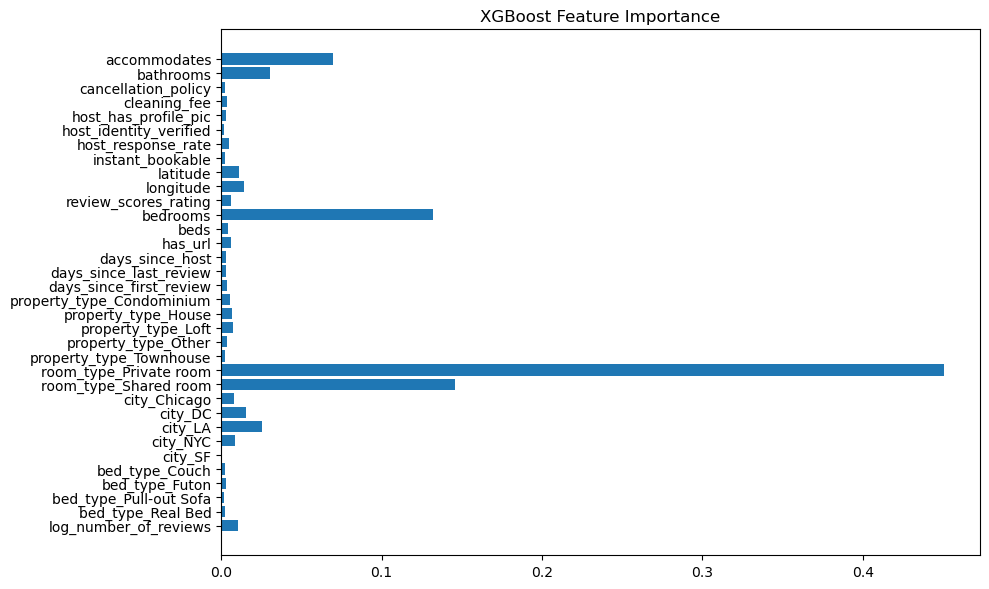

In [93]:
import matplotlib.pyplot as plt

xgb_importance = xgb_model.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(X_train.columns[::-1], xgb_importance[::-1])
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

**Performance Comparison Table**

| Model                        | RMSE   | MAE    | R²     | Notes                            |
|-----------------------------|--------|--------|--------|----------------------------------|
| **XGBoost**              | **0.3891** | 0.2821 | **0.7077** | Best performer                   |
| Full-Feature Random Forest  | 0.3920 | **0.2813** | 0.7033 | Very close second                |
| Tuned Random Forest (Top N) | 0.3946 | 0.2828 | 0.6994 | Similar to default RF               |
| Default Random Forest       | 0.3942 | 0.2825 | 0.6999 | Strong out of the box            |
| Ridge Regression            | 0.4617 | 0.3482 | 0.5884 | Matches Linear Regression        |
| Lasso Regression            | 0.4712 | 0.3576 | 0.5713 | Weakest model, does feature selection |
| Linear Regression (Baseline)| 0.4617 | 0.3482 | 0.5884 | Baseline                         |


**Retrain on Train + Validation**

In [101]:
# Combine features
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

In [102]:
xgb_model.fit(X_trainval, y_trainval)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [103]:
# Now lets evaluate our top performers in the test set:

### XGBoost:
# Predict with XGBoost
y_test_pred_xgb = xgb_model.predict(X_test)

# Evaluate
rmse_xgb_test = mean_squared_error(y_test, y_test_pred_xgb, squared=False)
mae_xgb_test = mean_absolute_error(y_test, y_test_pred_xgb)
r2_xgb_test = r2_score(y_test, y_test_pred_xgb)

print("XGBoost Test Set Performance:")
print(f"RMSE: {rmse_xgb_test:.4f}")
print(f"MAE: {mae_xgb_test:.4f}")
print(f"R²: {r2_xgb_test:.4f}")

XGBoost Test Set Performance:
RMSE: 0.3891
MAE: 0.2831
R²: 0.7035


In [104]:
best_rf_all.fit(X_trainval, y_trainval)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=10,
                      n_estimators=300, n_jobs=-1, random_state=0)

In [105]:
### RandomForest:
# Predict with Random Forest
y_test_pred_rf = best_rf_all.predict(X_test)

# Evaluate
rmse_rf_test = mean_squared_error(y_test, y_test_pred_rf, squared=False)
mae_rf_test = mean_absolute_error(y_test, y_test_pred_rf)
r2_rf_test = r2_score(y_test, y_test_pred_rf)

print("\nRandom Forest Test Set Performance:")
print(f"RMSE: {rmse_rf_test:.4f}")
print(f"MAE: {mae_rf_test:.4f}")
print(f"R²: {r2_rf_test:.4f}")


Random Forest Test Set Performance:
RMSE: 0.3923
MAE: 0.2826
R²: 0.6987


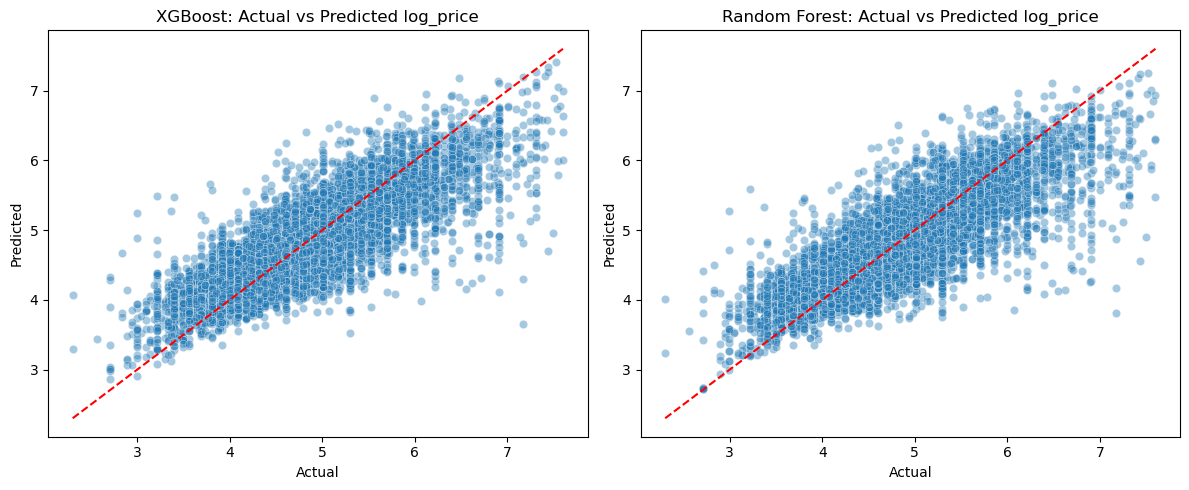

In [106]:
# Visual Comparison on Prediction:

plt.figure(figsize=(12, 5))

# XGBoost
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_test_pred_xgb, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("XGBoost: Actual vs Predicted log_price")
plt.xlabel("Actual")
plt.ylabel("Predicted")

# Random Forest
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_test_pred_rf, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Random Forest: Actual vs Predicted log_price")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

## Final Model Performance (Test Set) – Price Prediction

| Model         | RMSE   | MAE    | R²     | Notes                              |
|---------------|--------|--------|--------|-------------------------------------|
| **XGBoost**   | **0.3891** | 0.2831 | **0.7035** | Best overall model                |
| Random Forest | 0.3923 | **0.2826** | 0.6987 | Slightly lower MAE, still strong   |

- Models retrained on combined **Train + Validation** set for maximum performance
- Target variable: `log_price` 
- Performance measured on a completely unseen 20% test set
